In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:86% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror {font-family:Consolas; font-size:15pt;}
div.output {font-size:15pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:15pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:15px;}
</style>
"""))

In [5]:
import seaborn as sns
import pandas as pd
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Sequential, load_model, save_model
from tensorflow.keras.layers import Dense, Dropout,Input, add
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt

In [13]:
iris = sns.load_dataset('iris')
labelEncoder = LabelEncoder()
iris['y'] = labelEncoder.fit_transform(iris.species)
to_categorical(iris['y'])[::25]

array([[1., 0., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 0., 1.]], dtype=float32)

In [26]:
iris = sns.load_dataset('iris')
pd.get_dummies(iris.species).values  # 리스트
pd.get_dummies(iris.species)   # d-데이터 프레임 형태

,setosa,versicolor,virginica
0,1,0,0
1,1,0,0
2,1,0,0
3,1,0,0
4,1,0,0
...,...,...,...
145,0,0,1
146,0,0,1
147,0,0,1
148,0,0,1


In [31]:
from sklearn.model_selection import train_test_split
iris = sns.load_dataset('iris')
iris_x = iris.iloc[:, :-1].to_numpy()
iris_label = iris.iloc[:, -1]                         # 라벨: 문자열 상태로 둠
iris_y = pd.get_dummies(iris_label).values            # 원-핫 인코딩

x_train, x_test, y_train, y_test = train_test_split(
    iris_x, iris_y,
    test_size=0.2,
    stratify=iris_label,      # ✅ stratify는 문자열 라벨로
    random_state=7
)
print(iris_x.shape)
print(x_train.shape)

(150, 4)
(120, 4)


In [38]:
import numpy as np
print(pd.Series(np.argmax(iris_y, axis=1)).value_counts())


0    50
1    50
2    50
dtype: int64


In [42]:
# 2 모델구성
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# 모델 구성
model = Sequential()
model.add(Dense(units=64, input_dim=4, activation='relu'))
model.add(Dense(units=128, activation='relu'))   # 쉼표 추가
model.add(Dense(units=50, activation='relu'))
model.add(Dense(units=30, activation='relu'))
model.add(Dense(units=3, activation='softmax'))  # iris는 3클래스이므로 units=3

# 모델 요약 출력
model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 64)                320       
                                                                 
 dense_1 (Dense)             (None, 128)               8320      
                                                                 
 dense_2 (Dense)             (None, 50)                6450      
                                                                 
 dense_3 (Dense)             (None, 30)                1530      
                                                                 
 dense_4 (Dense)             (None, 3)                 93        
                                                                 
Total params: 16,713
Trainable params: 16,713
Non-trainable params: 0
_________________________________________________________________


In [60]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# 모델 컴파일
model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

# 모델 저장 폴더 및 파일 경로 설정
import os
model_save_folder = './model_iris/'
if not os.path.exists(model_save_folder):
    os.makedirs(model_save_folder)

file = model_save_folder + '/iris-{epoch:03d}-val{val_accuracy:.4f}.h5'

checkpoint = ModelCheckpoint(filepath=file,
                             monitor='val_accuracy',
                             save_best_only=True,
                             mode='max',
                             verbose=1)

# 조기 종료 설정
earlyStopping = EarlyStopping(monitor='val_loss',
                              patience=40,
                              mode='min',
                              verbose=1)

# 모델 학습
hist = model.fit(x_train, y_train,
                 epochs=500,
                 validation_split=0.2,
                 callbacks=[checkpoint, earlyStopping])


Epoch 1/500
1/3 [=========>....................] - ETA: 0s - loss: 0.0526 - accuracy: 0.9688
Epoch 1: val_accuracy improved from -inf to 0.91667, saving model to ./model_iris\iris-001-val0.9167.h5
3/3 [==============================] - 1s 95ms/step - loss: 0.0658 - accuracy: 0.9583 - val_loss: 0.2792 - val_accuracy: 0.9167
Epoch 2/500
1/3 [=========>....................] - ETA: 0s - loss: 0.0217 - accuracy: 1.0000
Epoch 2: val_accuracy did not improve from 0.91667
3/3 [==============================] - 0s 18ms/step - loss: 0.0592 - accuracy: 0.9688 - val_loss: 0.1602 - val_accuracy: 0.9167
Epoch 3/500
1/3 [=========>....................] - ETA: 0s - loss: 0.0751 - accuracy: 0.9688
Epoch 3: val_accuracy improved from 0.91667 to 0.95833, saving model to ./model_iris\iris-003-val0.9583.h5
3/3 [==============================] - 0s 31ms/step - loss: 0.0480 - accuracy: 0.9792 - val_loss: 0.2068 - val_accuracy: 0.9583
Epoch 4/500
1/3 [=========>....................] - ETA: 0s - loss: 0.0178 -

Epoch 31/500
1/3 [=========>....................] - ETA: 0s - loss: 0.0541 - accuracy: 0.9688
Epoch 31: val_accuracy did not improve from 0.95833
3/3 [==============================] - 0s 20ms/step - loss: 0.0397 - accuracy: 0.9792 - val_loss: 0.1747 - val_accuracy: 0.9167
Epoch 32/500
1/3 [=========>....................] - ETA: 0s - loss: 0.0108 - accuracy: 1.0000
Epoch 32: val_accuracy did not improve from 0.95833
3/3 [==============================] - 0s 16ms/step - loss: 0.0805 - accuracy: 0.9583 - val_loss: 0.1933 - val_accuracy: 0.9583
Epoch 33/500
1/3 [=========>....................] - ETA: 0s - loss: 0.0500 - accuracy: 0.9688
Epoch 33: val_accuracy did not improve from 0.95833
3/3 [==============================] - 0s 17ms/step - loss: 0.0766 - accuracy: 0.9688 - val_loss: 0.3823 - val_accuracy: 0.9167
Epoch 34/500
1/3 [=========>....................] - ETA: 0s - loss: 0.1329 - accuracy: 0.9688
Epoch 34: val_accuracy did not improve from 0.95833
3/3 [===========================

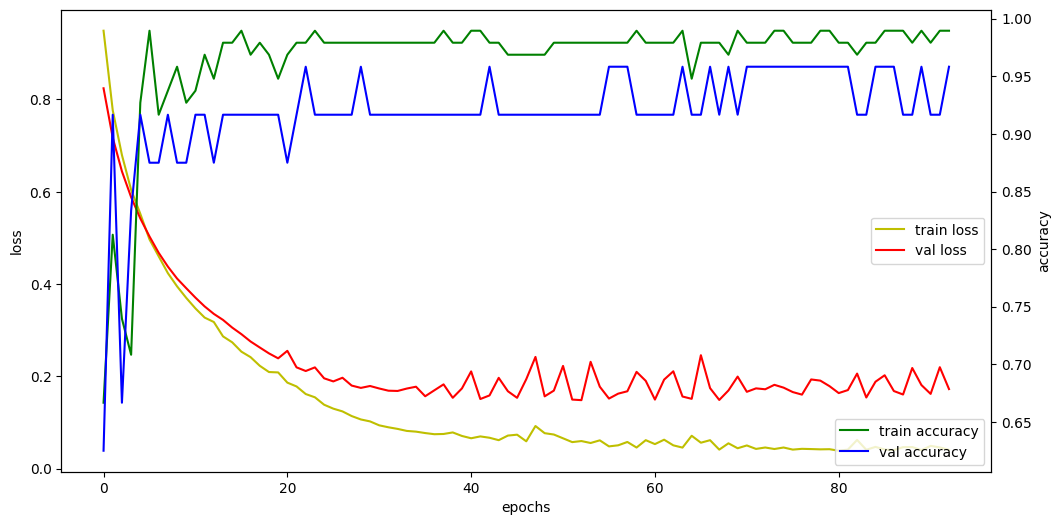

In [46]:
fig, loss_ax = plt.subplots(figsize=(12,6))
loss_ax.plot(hist.history['loss'], 'y', label='train loss')
loss_ax.plot(hist.history['val_loss'], 'r', label='val loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'], 'g', label='train accuracy')
acc_ax.plot(hist.history['val_accuracy'], 'b', label='val accuracy')
loss_ax.set_xlabel('epochs')
loss_ax.set_ylabel('loss')
acc_ax.set_ylabel('accuracy')
loss_ax.legend(loc='center right')
acc_ax.legend()
plt.show()

In [48]:
# 모델 평가
from sklearn.metrics import confusion_matrix
from sklearn.metrics import recall_score, precision_score, f1_score

loss, acc = model.evaluate(x_test, y_test)
loss, acc

1/1 [==============================] - 0s 24ms/step - loss: 0.0655 - accuracy: 0.9667


(0.06554171442985535, 0.9666666388511658)

In [50]:
real = np.argmax(y_test, axis=1)
pred = np.argmax(model.predict(x_test), axis=1)
recall = recall_score(real,pred,average='weighted')
precision = precision_score(real, pred, average='weighted')
f1 = f1_score(real, pred, average='weighted')
print(acc)
print(recall)
print(precision)
print(f1)

model.predict(x_test)

1/1 [==============================] - 0s 20ms/step
0.9666666388511658
0.9666666666666667
0.9696969696969696
0.9665831244778613
1/1 [==============================] - 0s 19ms/step


array([[9.2075043e-06, 3.6989284e-01, 6.3009793e-01],
       [9.9990797e-01, 9.1984672e-05, 8.6503404e-10],
       [9.9993932e-01, 6.0624803e-05, 5.0470700e-10],
       [6.9380847e-05, 9.8637915e-01, 1.3551516e-02],
       [1.5376491e-08, 2.1198362e-03, 9.9788022e-01],
       [9.6605356e-05, 9.9984598e-01, 5.7280795e-05],
       [1.4665921e-09, 5.4543256e-04, 9.9945456e-01],
       [9.9980623e-01, 1.9380455e-04, 4.5627142e-09],
       [2.7306580e-08, 1.3461040e-03, 9.9865389e-01],
       [6.6704278e-09, 1.3620912e-03, 9.9863786e-01],
       [2.1342136e-04, 9.9879408e-01, 9.9247694e-04],
       [9.9982566e-01, 1.7434142e-04, 1.4576809e-09],
       [9.9971181e-01, 2.8818194e-04, 7.9394429e-09],
       [7.5252188e-05, 9.9740040e-01, 2.5244062e-03],
       [2.4499048e-03, 9.9710101e-01, 4.4905738e-04],
       [9.0562901e-04, 9.9750441e-01, 1.5899166e-03],
       [9.9974650e-01, 2.5344425e-04, 4.5546855e-09],
       [9.9994290e-01, 5.7115380e-05, 3.7003403e-10],
       [7.5097276e-05, 9.969

In [63]:
model2 = load_model('model_iris/iris-003-val0.9583.h5')
loss, acc = model2.evaluate(x_test, y_test)
pred = model2.predict(x_test).argmax(axis=1)
recall = recall_score(real, pred, average='weighted')
precision = precision_score(real, pred, average='weighted')
f1 = f1_score(real, pred, average='weighted')
print('model2 loss :', loss)
print('model2 acc :', acc)
print('model2 recall :', recall)
print('model2 precision :', precision)
print('model2 f1 :', f1)

1/1 [==============================] - 0s 53ms/step
model2 loss : 0.03199657052755356
model2 acc : 1.0
model2 recall : 1.0
model2 precision : 1.0
model2 f1 : 1.0


In [64]:
pred = np.argmax(model.predict(x_test, verbose=0), axis=1)

In [69]:
# 교차표
pred = np.argmax(model.predict(x_test, verbose=0), axis=1)
pd.crosstab(real, pred,
         rownames=['real'], colnames=['pred'])

pred,0,1,2
real,,,
0,10,0,0
1,0,10,0
2,0,1,9


In [70]:
confusion_matrix(real, pred)

array([[10,  0,  0],
       [ 0, 10,  0],
       [ 0,  1,  9]], dtype=int64)

In [71]:
save_model(model, 'model/iris.h5')
model.save('model/iris.h5')

In [72]:
# 모델 예측하기
# iris.loc[100] (6.3, 3.3, 6.0, 2.5) 예측하기
result = model.predict([[6.3, 3.3, 6.1, 2.5]])
np.argmax(result) # virginica로 예측

1/1 [==============================] - 0s 36ms/step


2